[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/probability_statistics/09_maximum_likelihood_and_map_estimation/first_principles.ipynb)

# Module 09 — Maximum Likelihood and MAP Estimation

## 1. Why This Module Exists

A probability model is a machine that turns parameters into data distributions. Inference runs the machine backwards: the data are given, the parameters are not. The central move of parametric statistics is to take the very same function $p(x \mid \theta)$ and *change which argument is held fixed*. With $\theta$ fixed and $x$ varying it is a density describing randomness; with $x$ fixed and $\theta$ varying it is the **likelihood**, a score-card ranking candidate explanations of what actually happened.

Every supervised learning objective in current use is an instance of this construction. Squared error is the negative log-likelihood of Gaussian noise; cross-entropy is the negative log-likelihood of a categorical observation model; weight decay is a Gaussian prior; additive smoothing of $n$-gram counts is a Dirichlet prior. The module exists so that "choose a loss function" stops being a matter of taste and becomes a modeling statement with a checkable consequence: which estimator you get, how fast it concentrates, and how wide its error bars are.

The theory is unusually complete, and that completeness is the second reason for the module. Maximum likelihood comes with a closed-form answer to the question *how precise is this estimate?* — the Fisher information — and a theorem saying that no unbiased competitor can do better. Those two facts justify standard errors, confidence intervals, natural-gradient preconditioning, Laplace approximations to posteriors, and optimal experimental design, all from one identity.

The third reason is the failure modes. Maximum likelihood diverges on separable logistic regression, is unbounded for Gaussian mixtures, is biased for the Gaussian variance, converges at rate $n^{-1}$ rather than $n^{-1/2}$ when the support depends on the parameter, and quietly targets a KL projection instead of the truth when the model is wrong. Each pathology has a precise hypothesis behind it, and knowing which hypothesis broke is what tells you which fix applies.

## 2. Intuition

### 2.1 The Logarithm Is Not a Convenience

Three independent reasons make $\ell(\theta) = \ln L(\theta)$ the working object.

1. **Products become sums.** $\ell(\theta) = \sum_{i=1}^n \ln p(x_i \mid \theta)$, so $\ell/n$ is an *average* and the law of large numbers applies directly. This is what makes the asymptotic theory possible at all.
2. **Numerical survival.** A product of $10^6$ densities underflows to $0$ in double precision; a sum of $10^6$ log-densities does not.
3. **Geometry.** $\ln$ is strictly increasing, so the maximizer is unchanged, but the log-likelihood of an exponential family is concave in the natural parameter — a general optimization becomes a convex one.

Dividing by $n$ makes the connection to information theory explicit:

$$
-\frac{1}{n}\ell(\theta) = -\frac{1}{n}\sum_{i=1}^n \ln p(x_i \mid \theta) \xrightarrow[n\to\infty]{\text{a.s.}} -E_{p_0}\left[\ln p(X \mid \theta)\right] = H(p_0) + D_{\mathrm{KL}}\left(p_0 \parallel p_\theta\right) .
$$

The left side is the average negative log-likelihood — the cross-entropy loss of machine learning. The right side is a constant plus a KL divergence. Maximizing likelihood *is* minimizing KL divergence to the truth.

### 2.2 Curvature Is Information

Two datasets can select the same $\hat\theta$ yet differ enormously in how confident that choice is. The distinguishing feature is the *curvature* of the log-likelihood at its peak: a sharp spike means nearby parameters explain the data much worse, a flat ridge means they explain it nearly as well. Quantifying that curvature gives the Fisher information $I(\theta)$, and the asymptotic variance of the MLE is its inverse, $\operatorname{Var}(\hat\theta_n) \approx 1/(nI(\theta))$.

The picture to hold is that the log-likelihood, viewed near its peak, becomes a parabola of curvature $nI(\theta)$ as $n$ grows. Doubling the sample halves the width of that parabola in variance, i.e. shrinks the standard error by $\sqrt{2}$. Figure 1 draws exactly this.

### 2.3 Priors Enter as Regularizers

When data are scarce the likelihood can be maximized at absurd values: three coin flips landing heads give $\hat p = 1$, asserting that tails is impossible. Prior information fixes this. Bayes' rule gives $p(\theta \mid x) \propto p(x\mid\theta)\,p(\theta)$, and taking logs turns the product into a sum:

$$
\hat\theta_{\text{MAP}} = \operatorname*{arg\,max}_\theta \Big[\underbrace{\ell(\theta)}_{\text{fit}} + \underbrace{\ln p(\theta)}_{-\text{penalty}}\Big] .
$$

Because $\ell$ grows like $n$ while $\ln p(\theta)$ does not, the prior's influence decays as $O(1/n)$: it dominates when data are few and vanishes when data are plentiful. This single line explains why weight decay helps small models more than large-data regimes, and why smoothing constants matter for rare $n$-grams but not for frequent ones.

The first code cell is the module preamble. Everything below draws its randomness from the single generator `rng`, so every printed number in this notebook is reproducible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

from scipy import optimize, stats
from scipy.special import expit, logsumexp

print("numpy", np.__version__)

numpy 2.4.6


**Figure 1 checks the claim of Section 2.2**: that the log-likelihood near its maximum is a parabola whose curvature grows linearly in $n$, so that the half-width of the peak shrinks like $n^{-1/2}$. We draw the *centred, per-observation* log-likelihood $\frac{1}{n}\left[\ell_n(p) - \ell_n(\hat p)\right]$ for Bernoulli samples of size $5$, $50$ and $500$ drawn from $p_0 = 0.3$, together with the interval $\hat p \pm 1/\sqrt{n I(\hat p)}$ predicted by the Fisher information.

n =    5   p-hat = 0.2000   I(p-hat) =  6.2500   se = 0.1789
n =   50   p-hat = 0.3200   I(p-hat) =  4.5956   se = 0.0660
n =  500   p-hat = 0.3400   I(p-hat) =  4.4563   se = 0.0212


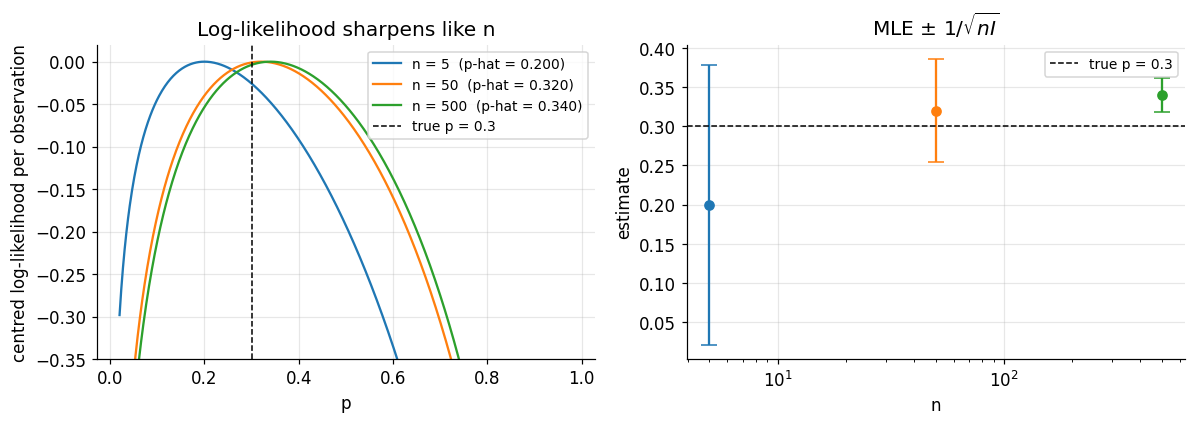

In [2]:
p0, sizes = 0.3, (5, 50, 500)
grid = np.linspace(0.02, 0.98, 800)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))
for n in sizes:
    x = rng.binomial(1, p0, size=n)
    k = x.sum()
    phat = k / n
    ell = k * np.log(grid) + (n - k) * np.log1p(-grid)
    axes[0].plot(grid, (ell - ell.max()) / n, label=f"n = {n}  (p-hat = {phat:.3f})")
    se = 1.0 / np.sqrt(n / (phat * (1 - phat)))          # 1 / sqrt(n I(p-hat))
    axes[1].errorbar(n, phat, yerr=se, fmt="o", capsize=5)
    print(f"n = {n:4d}   p-hat = {phat:.4f}   I(p-hat) = {1/(phat*(1-phat)):7.4f}"
          f"   se = {se:.4f}")

axes[0].axvline(p0, color="k", ls="--", lw=1, label="true p = 0.3")
axes[0].set_xlabel("p"); axes[0].set_ylabel("centred log-likelihood per observation")
axes[0].set_title("Log-likelihood sharpens like n")
axes[0].set_ylim(-0.35, 0.02); axes[0].legend(fontsize=9)

axes[1].axhline(p0, color="k", ls="--", lw=1, label="true p = 0.3")
axes[1].set_xscale("log"); axes[1].set_xlabel("n"); axes[1].set_ylabel("estimate")
axes[1].set_title(r"MLE $\pm\ 1/\sqrt{nI}$"); axes[1].legend(fontsize=9)
fig.tight_layout()
plt.show()

The left panel shows the peak narrowing by roughly a factor $\sqrt{10}$ each time $n$ grows tenfold, exactly as $\operatorname{Var}(\hat p) \approx 1/(nI)$ predicts; the right panel shows the corresponding error bars contracting around $p_0 = 0.3$. Nothing here is proved yet — Sections 4 and 5 supply the theorem that licenses the picture.

## 3. Definitions

### Definition 3.1 (Likelihood and log-likelihood)

For a statistical model $\{p(\cdot \mid \theta) : \theta \in \Theta \subseteq \mathbb{R}^d\}$ and observed data $x = (x_1,\ldots,x_n)$,

$$
L(\theta) = p(x \mid \theta), \qquad \ell(\theta) = \ln L(\theta) = \sum_{i=1}^n \ln p(x_i \mid \theta) \ \ \text{(i.i.d. case)} .
$$

Likelihoods are defined up to a positive multiplicative constant not depending on $\theta$; only ratios carry meaning.

### Definition 3.2 (Maximum likelihood estimator)

$$
\hat\theta_{\text{MLE}} \in \operatorname*{arg\,max}_{\theta \in \Theta} \ell(\theta) .
$$

At an interior maximum with differentiable $\ell$, $\hat\theta$ solves the *score equation* $\nabla_\theta \ell(\hat\theta) = 0$; boundary maxima must be found by direct inspection.

### Definition 3.3 (Score function)

$$
s(\theta; x) = \nabla_\theta \ln p(x \mid \theta) .
$$

### Definition 3.4 (Fisher information)

For a single observation,

$$
I(\theta) = E_\theta\left[s(\theta; X)\,s(\theta; X)^{\top}\right] .
$$

For $n$ i.i.d. observations the total information is $nI(\theta)$, because scores of independent observations are independent and mean zero, so their covariances add.

### Definition 3.5 (Observed information)

$\hat J_n = -\nabla^2_\theta \ell_n(\hat\theta_n)$, the negative Hessian of the log-likelihood evaluated at the MLE. Unlike $I(\theta)$ it involves no expectation and is computable from the sample alone.

### Definition 3.6 (Consistency and efficiency)

$\hat\theta_n$ is **consistent** if $\hat\theta_n \xrightarrow{P} \theta_0$ under the true parameter $\theta_0$. An unbiased estimator is **efficient** if its variance equals the Cramér–Rao bound of Theorem 4.3; it is **asymptotically efficient** if $n\operatorname{Var}(\hat\theta_n) \to I(\theta_0)^{-1}$.

### Definition 3.7 (MAP estimator)

Given a prior density $p(\theta)$,

$$
\hat\theta_{\text{MAP}} = \operatorname*{arg\,max}_{\theta} p(\theta \mid x) = \operatorname*{arg\,max}_\theta \left[\ell(\theta) + \ln p(\theta)\right] .
$$

### Definition 3.8 (Exponential family)

A family is exponential in canonical form if

$$
p(x \mid \eta) = h(x)\exp\left(\eta^{\top} T(x) - A(\eta)\right) ,
$$

with sufficient statistic $T$, natural parameter $\eta$, and log-partition $A$. Differentiating $\int p = 1$ twice gives $\nabla A(\eta) = E[T(X)]$ and $\nabla^2 A(\eta) = \operatorname{Cov}(T(X)) = I(\eta)$, so $A$ is convex and $\ell$ is concave in $\eta$.

### Definition 3.9 (Sufficient statistic)

$T(X)$ is **sufficient** for $\theta$ if the conditional law of $X$ given $T(X) = t$ does not depend on $\theta$. It is **minimal sufficient** if it is a function of every other sufficient statistic.

### Definition 3.10 (Complete statistic)

$T(X)$ is **complete** for the family $\{p_\theta\}$ if the only measurable $g$ with $E_\theta[g(T)] = 0$ for every $\theta \in \Theta$ is $g = 0$ almost surely. Completeness says the family of induced laws of $T$ is rich enough to have no nontrivial unbiased estimator of zero.

## 4. Main Results

Every theorem below is stated with its hypotheses inline, followed by one line per hypothesis saying what it buys. The standing **regularity conditions** are:

- **(R1)** the support $\{x : p(x\mid\theta) \gt 0\}$ does not depend on $\theta$;
- **(R2)** $\theta \mapsto p(x\mid\theta)$ is twice continuously differentiable on an open $\Theta$;
- **(R3)** differentiation under the integral sign in $\int p(x\mid\theta)\,dx$ is legitimate, twice;
- **(R4)** the model is identifiable: $p_\theta = p_{\theta'}$ implies $\theta = \theta'$;
- **(R5)** $I(\theta)$ exists, is finite and nonsingular.

### Theorem 4.1 (Invariance of the MLE)

Let $\hat\theta$ maximize $L$ over $\Theta$ and let $g : \Theta \to \mathcal{H}$ be any function. Then $g(\hat\theta)$ maximizes the induced profile likelihood $L^{*}(\eta) = \sup\{L(\theta) : g(\theta) = \eta\}$, so $\widehat{g(\theta)} = g(\hat\theta)$.

No regularity is needed: the statement is about suprema, not derivatives, which is why it also covers boundary and non-smooth cases. Proved in Proof 5.2.

### Theorem 4.2 (Score identities and the information equality)

Assume (R1)–(R3). Then

$$
E_\theta\left[s(\theta; X)\right] = 0, \qquad I(\theta) = \operatorname{Cov}_\theta\left(s(\theta;X)\right) = -E_\theta\left[\nabla_\theta^2 \ln p(X\mid\theta)\right] .
$$

- (R1) is what makes $\int p\,dx$ differentiable in $\theta$ at all: with a moving support the boundary contributes an extra term and the score acquires a nonzero mean.
- (R2) supplies the second derivative appearing on the right.
- (R3) is the exchange of $\nabla_\theta$ and $\int dx$ that the proof performs twice.

Proved in Proof 5.3.

### Theorem 4.3 (Cramér–Rao lower bound)

Assume (R1)–(R3), (R5), and let $T = T(X_1,\ldots,X_n)$ satisfy $E_\theta[T] = g(\theta)$ for every $\theta$, with $g$ differentiable and $\operatorname{Var}_\theta(T) \lt \infty$. Then

$$
\operatorname{Var}_\theta(T) \ \ge\ \frac{\left[g'(\theta)\right]^2}{n\,I(\theta)} , \qquad \text{in particular } \operatorname{Var}_\theta(T) \ \ge\ \frac{1}{n I(\theta)} \text{ when } g(\theta) = \theta .
$$

Equality holds if and only if $T - g(\theta) = c(\theta)\,s_n(\theta)$ almost surely for some scalar $c(\theta)$.

- (R1)–(R3) let the proof differentiate $E_\theta[T] = g(\theta)$ under the integral; without them the covariance identity $\operatorname{Cov}(T,s_n) = g'(\theta)$ fails, and $\operatorname{Unif}(0,\theta)$ is the standard counterexample where the "bound" is beaten.
- Unbiasedness *for every* $\theta$ (not at one point) is what makes the derivative of the constraint meaningful; biased estimators such as ridge are simply outside the class.
- (R5) is needed to divide by $I(\theta)$.
- Finite variance is needed for Cauchy–Schwarz.

Multivariate form: $\operatorname{Cov}(T) \succeq \left[nI(\theta)\right]^{-1}$ in the Loewner order. Proved in Proof 5.4.

### Theorem 4.4 (Consistency of the MLE)

Assume (R4), $\Theta$ compact, $\theta \mapsto \ln p(x\mid\theta)$ continuous for almost every $x$, and an integrable envelope $\sup_{\theta}\left\vert \ln p(x\mid\theta) - \ln p(x \mid \theta_0)\right\vert \le F(x)$ with $E_{\theta_0}[F] \lt \infty$. Then $\hat\theta_n \xrightarrow{P}\theta_0$.

- Identifiability (R4) is what upgrades "the KL divergence is zero" to "the parameters are equal"; without it the MLE converges to a set, not a point.
- Compactness prevents the maximizer escaping to infinity along a direction where the likelihood does not decrease.
- Continuity plus the envelope give the *uniform* law of large numbers, which is what transfers convergence of the objective to convergence of its maximizer.

Proved in Proof 5.5.

### Theorem 4.5 (Asymptotic normality and efficiency of the MLE)

Assume (R1)–(R5), that $\theta_0$ is interior to $\Theta$, that $\hat\theta_n$ is consistent, and that the third derivatives of $\ln p$ are dominated near $\theta_0$ by an integrable function. Then

$$
\sqrt{n}\left(\hat\theta_n - \theta_0\right) \xrightarrow{d} \mathcal{N}\left(0, \ I(\theta_0)^{-1}\right) .
$$

- Interiority gives the score equation $\nabla\ell_n(\hat\theta_n) = 0$; on a boundary the expansion has no zero to expand around, which is why $\operatorname{Unif}(0,\theta)$ escapes the theorem.
- Consistency is what places the Taylor expansion's intermediate points near $\theta_0$.
- The dominated third derivative is what makes the row-wise Hessians in the mean value expansion converge to the *same* limit $-I(\theta_0)$.
- Nonsingular $I(\theta_0)$ is needed to invert the limit.

$$
\boxed{\ \sqrt{n}\left(\hat\theta_n-\theta_0\right)\ \xrightarrow{d}\ \mathcal{N}\left(0,\ I(\theta_0)^{-1}\right)\ }
$$

**Interpretation.** The MLE is asymptotically unbiased and normal with variance equal to the Cramér–Rao bound of Theorem 4.3: to first order, no unbiased procedure extracts more from the sample. The consequence is operational — an estimate, a standard error and a confidence interval all come from one optimization plus one Hessian, with no distribution-specific tables.

### Theorem 4.6 (MAP estimation is penalized likelihood)

Let $y = Xw + \varepsilon$ with $\varepsilon \sim \mathcal{N}(0,\sigma^2 I_n)$ and $\sigma^2$ known. Fix once and for all the **unscaled objective** $\lVert y - Xw\rVert_2^2 + \text{penalty}$, obtained by multiplying $-2\sigma^2 \ln p(w \mid y)$ and discarding constants. Then

$$
w \sim \mathcal{N}(0,\tau^2 I_d) \ \Longrightarrow\ \text{penalty } \lambda\lVert w\rVert_2^2 \ \text{ with } \lambda = \frac{\sigma^2}{\tau^2}; \qquad
w_j \sim \text{Laplace}(0,b) \ \Longrightarrow\ \text{penalty } \lambda\lVert w\rVert_1 \ \text{ with } \lambda = \frac{2\sigma^2}{b} .
$$

For $k$ successes in $n$ Bernoulli trials with $p\sim\text{Beta}(\alpha,\beta)$, $\alpha,\beta \gt 1$,

$$
\hat p_{\text{MAP}} = \frac{k+\alpha-1}{n+\alpha+\beta-2} .
$$

- Gaussian noise is what turns the log-likelihood into a squared norm; Laplace noise would give an $\ell_1$ *data* term instead.
- Known $\sigma^2$ is what makes $\lambda$ a constant rather than a quantity re-estimated at each step.
- $\alpha,\beta \gt 1$ keeps the Beta density's mode interior; for $\alpha \lt 1$ the density diverges at $0$ and the MAP is pushed to the boundary.

Proved in Proof 5.7. **The normalization matters**: with the objective written instead as $\frac{1}{2\sigma^2}\lVert y - Xw\rVert_2^2 + \lambda\lVert w\rVert_2^2$ the same prior gives $\lambda = 1/(2\tau^2)$. Every statement in this module uses the unscaled objective, so $\lambda = \sigma^2/\tau^2$ throughout.

### Theorem 4.7 (EM never decreases the likelihood)

Let $p(x,z\mid\theta)$ be a joint model with latent $z$, let $q^{(t)}(z) = p(z\mid x,\theta^{(t)})$ (E-step) and let $\theta^{(t+1)}$ maximize $E_{q^{(t)}}\left[\ln p(x,z\mid\theta)\right]$ over $\theta$ (M-step). Assume the E-step posterior is computable and the M-step maximum exists. Then $\ell(\theta^{(t+1)}) \ge \ell(\theta^{(t)})$ for every $t$.

- Exactness of the E-step is what makes the variational bound *tight* at $\theta^{(t)}$; an approximate posterior gives only the ELBO, which still increases but no longer certifies an increase of $\ell$.
- Existence of the M-step maximum is what supplies the middle inequality; a partial M-step ("generalized EM") suffices provided it does not decrease $Q$.

Proved in Proof 5.8.

### Theorem 4.8 (Fisher–Neyman factorization; cited, not proved here)

$T(X)$ is sufficient for $\theta$ if and only if $p(x\mid\theta) = g\left(T(x),\theta\right)h(x)$ for some non-negative $g,h$. A consequence used repeatedly below: since $\ell(\theta) = \ln g(T(x),\theta) + \ln h(x)$, the MLE depends on the data only through $T$.

Reference: Casella & Berger, *Statistical Inference*, 2nd ed., §6.2.1, Theorem 6.2.6 (discrete case proved there in full; the general case needs measure-theoretic conditional densities and is Lehmann & Casella, *Theory of Point Estimation*, 2nd ed., §1.6, Theorem 6.5). The discrete case is a two-line rearrangement of the definition and is what every example in this module uses.

### Theorem 4.9 (Rao–Blackwell)

Let $T$ be sufficient for $\theta$ and let $W$ be any estimator of $g(\theta)$ with $E_\theta[W^2] \lt \infty$. Define $\phi(T) = E[W \mid T]$. Then $\phi$ is a statistic (it does not depend on $\theta$), $E_\theta[\phi] = E_\theta[W]$, and

$$
\operatorname{Var}_\theta(\phi) \ \le\ \operatorname{Var}_\theta(W) \quad \text{for every } \theta ,
$$

with equality if and only if $W$ is already a function of $T$ almost surely.

- Sufficiency is exactly what makes $E[W\mid T]$ free of $\theta$; conditioning on a non-sufficient statistic produces something that is not an estimator.
- Finite second moment is needed for the variance decomposition.

Proved in Proof 5.9.

### Theorem 4.10 (Lehmann–Scheffé)

If $T$ is **complete** and sufficient for $\theta$ and $\phi(T)$ is unbiased for $g(\theta)$, then $\phi(T)$ is the unique uniformly minimum-variance unbiased estimator (UMVUE) of $g(\theta)$.

- Sufficiency lets Rao–Blackwell improve any competitor down to a function of $T$.
- Completeness is what makes that function unique: two unbiased functions of $T$ differ by an unbiased estimator of zero, which completeness forces to vanish.

Proved in Proof 5.9. This is the theorem exercise L1.2 invokes for $\operatorname{Unif}(0,\theta)$.

### Theorem 4.11 (Wilks; cited here, proved in exercise L3.4)

Let $\Theta \subseteq \mathbb{R}^d$ and let $\Theta_0 \subseteq \Theta$ be a smooth submanifold of dimension $d-k$ containing the true $\theta_0$ in its relative interior, with $\theta_0$ interior to $\Theta$ and (R1)–(R5) in force. Then under $H_0 : \theta \in \Theta_0$,

$$
\Lambda_n = 2\left[\ell(\hat\theta) - \ell(\hat\theta_0)\right] \ \xrightarrow{d}\ \chi^2_k ,
$$

where $\hat\theta$ and $\hat\theta_0$ are the unconstrained and constrained maximizers.

- Interiority of $\theta_0$ in $\Theta_0$ is essential: testing a variance component $\sigma^2 = 0$ puts $\theta_0$ on the boundary and the limit becomes the mixture $\tfrac12\chi^2_0 + \tfrac12\chi^2_1$.
- Nested, identified models are essential: if a nuisance parameter is unidentified under $H_0$ (testing the number of mixture components) the limit is not $\chi^2$ at all.
- $k$ is the number of *constrained directions*, not the dimension of either model.

The proof — quadratic expansion, whitening, and Cochran's theorem — is Problem L3.4 of `exercises.ipynb`, where it is carried out in full. It is stated here because Section 8 and the AIC discussion both use it.

## 5. Derivations and Proofs

### Derivation 5.1 — Closed-Form MLEs in Four Models

**(a) Bernoulli($p$).** With $k = \sum_i x_i$ successes in $n$ trials,

$$
\ell(p) = k\ln p + (n-k)\ln(1-p), \qquad \ell'(p) = \frac{k}{p} - \frac{n-k}{1-p} .
$$

Setting $\ell' = 0$ gives $k(1-p) = (n-k)p$, hence $k = np$ and $\hat p = k/n = \bar{x}$. The second derivative $\ell''(p) = -k/p^2 - (n-k)/(1-p)^2 \lt 0$ confirms a maximum.

**(b) Gaussian $\mathcal{N}(\mu, \sigma^2)$, both unknown.**

$$
\ell(\mu,\sigma^2) = -\frac{n}{2}\ln(2\pi) - \frac{n}{2}\ln\sigma^2 - \frac{1}{2\sigma^2}\sum_{i=1}^n (x_i-\mu)^2 .
$$

Differentiating in $\mu$: $\frac{1}{\sigma^2}\sum_i (x_i - \mu) = 0 \Rightarrow \hat\mu = \bar{x}$. Differentiating in $v = \sigma^2$,

$$
\frac{\partial \ell}{\partial v} = -\frac{n}{2v} + \frac{1}{2v^2}\sum_i (x_i-\hat\mu)^2 = 0 \quad \Longrightarrow \quad \hat\sigma^2 = \frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^2 .
$$

Note the divisor $n$, not $n-1$: since $E[\hat\sigma^2] = \frac{n-1}{n}\sigma^2$, the MLE is biased low. Bias is unavoidable if invariance is desired — $\widehat{\sigma} = \sqrt{\hat\sigma^2}$ must follow from $\hat\sigma^2$ by Theorem 4.1, and no single convention can debias every reparameterization.

**(c) Poisson($\lambda$).** $\ell(\lambda) = -n\lambda + \left(\sum_i x_i\right)\ln\lambda - \sum_i \ln(x_i!)$, so $\ell'(\lambda) = -n + \frac{\sum_i x_i}{\lambda} = 0$ gives $\hat\lambda = \bar{x}$.

**(d) Uniform $\text{Unif}(0,\theta)$ — a boundary case.** $L(\theta) = \theta^{-n}\mathbf{1}\{\theta \ge \max_i x_i\}$ is *decreasing* wherever it is positive, so calculus never applies; the maximum sits at the constraint boundary, $\hat\theta = \max_i x_i = x_{(n)}$. Hypothesis (R1) fails here, and with it Theorems 4.3 and 4.5: the estimator converges at rate $n$, not $\sqrt{n}$, with an exponential rather than normal limit. $\blacksquare$

### Proof 5.2 (of Theorem 4.1 — invariance)

Let $\eta = g(\theta)$ and $L^{*}(\eta) = \sup\{L(\theta) : g(\theta) = \eta\}$, the profile likelihood induced by $g$. For every $\eta$ in the range of $g$,

$$
L^{*}(\eta) = \sup_{\theta \in g^{-1}(\eta)} L(\theta) \ \le\ \sup_{\theta\in\Theta} L(\theta) = L(\hat\theta) ,
$$

and the value $L(\hat\theta)$ is attained by $L^{*}$ at $\eta = g(\hat\theta)$, since $\hat\theta \in g^{-1}(g(\hat\theta))$. Hence $g(\hat\theta) \in \operatorname*{arg\,max}_\eta L^{*}(\eta)$. Because $L^{*}$ reduces to $L$ when $g$ is a bijection, this is a genuine extension of the ordinary definition rather than a new convention. $\blacksquare$

### Proof 5.3 (of Theorem 4.2 — score identities and the information equality)

**Mean zero.** Start from the normalization $\int p(x\mid\theta)\,dx = 1$, valid for every $\theta$ because of (R1), and differentiate both sides in $\theta$. Hypothesis (R3) licenses exchanging derivative and integral:

$$
0 = \nabla_\theta \int p(x\mid\theta)\,dx = \int \nabla_\theta p(x\mid\theta)\,dx .
$$

Now use the log-derivative identity $\nabla_\theta p = p\,\nabla_\theta \ln p$, valid wherever $p \gt 0$ — which by (R1) is a $\theta$-free set:

$$
0 = \int p(x\mid\theta)\,\nabla_\theta \ln p(x\mid\theta)\,dx = E_\theta\left[s(\theta;X)\right] .
$$

Consequently $I(\theta) = E[ss^{\top}] = \operatorname{Cov}(s)$ with no centering correction.

**Information equality.** Differentiate the identity $\int p\,\nabla_\theta \ln p \,dx = 0$ once more, again exchanging by (R3) and using (R2) for the second derivative:

$$
0 = \int \nabla_\theta\left[p\,\left(\nabla_\theta \ln p\right)^{\top}\right] dx = \int \left(\nabla_\theta p\right)\left(\nabla_\theta \ln p\right)^{\top} dx + \int p\,\nabla^2_\theta \ln p\ dx .
$$

Apply the log-derivative identity to the first term:

$$
0 = E\left[\left(\nabla_\theta \ln p\right)\left(\nabla_\theta\ln p\right)^{\top}\right] + E\left[\nabla^2_\theta \ln p\right] = I(\theta) + E\left[\nabla^2_\theta \ln p\right] . \qquad \blacksquare
$$

$$
\boxed{\ I(\theta) \;=\; E_\theta\!\left[s\,s^{\top}\right] \;=\; -\,E_\theta\!\left[\nabla_\theta^2 \ln p(X\mid\theta)\right]\ }
$$

**Interpretation.** Information is measured equivalently by how much the score fluctuates (a first-order, variance statement) or by how sharply the log-likelihood curves down at the truth (a second-order, geometric statement). The consequence is that one Hessian computation delivers both the optimization step and the error bar. The equality fails as soon as the model is misspecified, and the discrepancy between the two sides is precisely what the sandwich covariance of exercise L3.2 repairs.

**Bernoulli check.** $\ln p(x\mid p) = x\ln p + (1-x)\ln(1-p)$, so $s = \frac{x}{p} - \frac{1-x}{1-p} = \frac{x - p}{p(1-p)}$ and

$$
I(p) = \operatorname{Var}\left(\frac{X-p}{p(1-p)}\right) = \frac{p(1-p)}{p^2(1-p)^2} = \frac{1}{p(1-p)} ,
$$

which blows up as $p \to 0$ or $1$: extreme probabilities are *easy* to pin down on the natural scale.

### Proof 5.4 (of Theorem 4.3 — the Cramér–Rao bound)

Write $s_n(\theta) = \sum_{i=1}^n s(\theta; X_i)$ for the total score. By Theorem 4.2 and independence, $E[s_n] = 0$ and $\operatorname{Var}(s_n) = nI(\theta)$.

**Step 1 — covariance identity.** Differentiate the unbiasedness relation $E_\theta[T] = \int T(x)p(x\mid\theta)\,dx = g(\theta)$ in $\theta$, exchanging by (R3):

$$
g'(\theta) = \int T(x)\,\nabla_\theta p(x\mid\theta)\,dx = \int T(x)\,s_n(\theta;x)\,p(x\mid\theta)\,dx = E\left[T\,s_n\right] .
$$

Since $E[s_n] = 0$, this says $\operatorname{Cov}(T, s_n) = g'(\theta)$.

**Step 2 — Cauchy–Schwarz.** For square-integrable $T$ and $s_n$,

$$
\operatorname{Cov}(T, s_n)^2 \le \operatorname{Var}(T)\,\operatorname{Var}(s_n) .
$$

Substituting the two computed quantities,

$$
\left[g'(\theta)\right]^2 \le \operatorname{Var}(T)\cdot nI(\theta) \quad \Longrightarrow \quad \operatorname{Var}(T) \ge \frac{\left[g'(\theta)\right]^2}{nI(\theta)} . \qquad \blacksquare
$$

**Equality condition.** Cauchy–Schwarz is tight exactly when $T - g(\theta)$ and $s_n(\theta)$ are almost surely proportional, $T - g(\theta) = c(\theta)s_n(\theta)$. Integrating that differential relation in $\theta$ shows the model must be an exponential family with $T$ its natural sufficient statistic — which is why $\bar{X}$ is efficient for the Gaussian mean and the Poisson rate, while no unbiased estimator of $e^{-\lambda}$ is efficient at finite $n$.

**Caveat.** Unbiasedness is essential, not decorative. Ridge regression, James–Stein shrinkage and every MAP estimate are biased, and $\text{MSE} = \text{bias}^2 + \text{variance}$ lets them trade a little of the first for a lot of the second; exercise L3.1(c) computes the trade explicitly.

### Proof 5.5 (of Theorem 4.4 — consistency via KL divergence)

Define the normalized log-likelihood ratio

$$
M_n(\theta) = \frac{1}{n}\sum_{i=1}^n \ln \frac{p(X_i\mid\theta)}{p(X_i \mid \theta_0)} .
$$

Maximizing $M_n$ is equivalent to maximizing $\ell_n$, since the denominator does not involve $\theta$.

**Step 1 — pointwise limit.** By the strong law of large numbers, for each fixed $\theta$,

$$
M_n(\theta) \xrightarrow{a.s.} M(\theta) = E_{\theta_0}\left[\ln\frac{p(X\mid\theta)}{p(X\mid\theta_0)}\right] = -D_{\mathrm{KL}}\left(p_{\theta_0}\parallel p_\theta\right) .
$$

The envelope hypothesis is what makes the expectation finite.

**Step 2 — the limit is uniquely maximized at $\theta_0$.** By Jensen's inequality applied to the concave $\ln$,

$$
M(\theta) = E_{\theta_0}\left[\ln \frac{p(X\mid\theta)}{p(X\mid\theta_0)}\right] \le \ln E_{\theta_0}\left[\frac{p(X\mid\theta)}{p(X\mid\theta_0)}\right] = \ln\int p(x\mid\theta)\,dx = \ln 1 = 0 ,
$$

with equality iff the ratio is almost surely constant, i.e. $p_\theta = p_{\theta_0}$, which identifiability (R4) upgrades to $\theta = \theta_0$. So $M(\theta_0) = 0 \gt M(\theta)$ for every $\theta \ne \theta_0$. Note that this step uses no derivative of $\ell$ and therefore proves nothing about *how* the maximizer is found — only where it is.

**Step 3 — uniformity transfers the maximizer.** With $\Theta$ compact, $\theta\mapsto\ln p(x\mid\theta)$ continuous and the envelope integrable, the convergence in Step 1 is uniform:

$$
\sup_{\theta\in\Theta}\left\vert M_n(\theta) - M(\theta)\right\vert \xrightarrow{P} 0 .
$$

Fix a neighbourhood $U$ of $\theta_0$. By Step 2 and compactness of $\Theta\setminus U$, $\delta := -\sup_{\theta \notin U} M(\theta) \gt 0$. On the event $\sup_\theta\vert M_n - M\vert \lt \delta/2$ we have, for every $\theta\notin U$,

$$
M_n(\theta) \lt M(\theta) + \tfrac{\delta}{2} \le -\delta + \tfrac{\delta}{2} = -\tfrac{\delta}{2} \lt M_n(\theta_0) ,
$$

the last inequality because $M_n(\theta_0) = 0$. Hence the maximizer $\hat\theta_n$ lies in $U$, and that event has probability tending to $1$. $\blacksquare$

**Interpretation.** Consistency is the statement that the empirical log-likelihood ratio converges to a negative KL divergence and that KL separates distinct distributions. Under misspecification the same argument gives $\hat\theta_n \to \theta^{\star} = \operatorname*{arg\,min}_\theta D_{\mathrm{KL}}(p_0 \parallel p_\theta)$ — the MLE finds the KL-closest member of the family, which is exactly what a network trained with cross-entropy does.

### Proof 5.6 (of Theorem 4.5 — asymptotic normality)

Let $\ell_n(\theta) = \sum_i \ln p(X_i\mid\theta)$. Since $\theta_0$ is interior and $\hat\theta_n \xrightarrow{P}\theta_0$, with probability tending to one $\hat\theta_n$ is interior too and satisfies $\nabla\ell_n(\hat\theta_n) = 0$.

**Step 1 — a row-wise mean value expansion.** Apply the one-dimensional mean value theorem to each coordinate $j = 1,\ldots,d$ of the map $t \mapsto \partial_j \ell_n\left(\theta_0 + t(\hat\theta_n - \theta_0)\right)$. This produces *one intermediate point per coordinate*, $\tilde\theta_n^{(j)}$ on the segment joining $\theta_0$ and $\hat\theta_n$, with

$$
0 = \partial_j \ell_n(\hat\theta_n) = \partial_j\ell_n(\theta_0) + \left[\nabla \partial_j \ell_n\left(\tilde\theta_n^{(j)}\right)\right]^{\top}\left(\hat\theta_n - \theta_0\right), \qquad j = 1,\ldots,d .
$$

There is in general **no single** $\tilde\theta_n$ that works for all coordinates — the multivariate mean value theorem is false in that form. Stacking the $d$ equations defines the matrix $\bar{H}_n$ whose $j$-th *row* is $\nabla\partial_j\ell_n(\tilde\theta_n^{(j)})^{\top}$, so that $0 = \nabla\ell_n(\theta_0) + \bar{H}_n(\hat\theta_n - \theta_0)$ and

$$
\sqrt{n}\left(\hat\theta_n - \theta_0\right) = \left[-\tfrac{1}{n}\bar{H}_n\right]^{-1}\left[\tfrac{1}{\sqrt{n}}\nabla\ell_n(\theta_0)\right] ,
$$

on the event that $\bar H_n$ is invertible, whose probability tends to one by Step 3.

**Step 2 — numerator, a CLT.** $\frac{1}{\sqrt n}\nabla\ell_n(\theta_0)$ is a standardized sum of i.i.d. scores with mean $0$ and covariance $I(\theta_0)$ (Proof 5.3), so by the multivariate central limit theorem

$$
\frac{1}{\sqrt n}\nabla\ell_n(\theta_0)\ \xrightarrow{d}\ \mathcal{N}\left(0, I(\theta_0)\right) .
$$

**Step 3 — denominator, a uniform LLN.** Each row is evaluated at a *different* point, so an ordinary LLN is not enough. Write, for row $j$,

$$
\left\lVert \tfrac1n\nabla\partial_j\ell_n\left(\tilde\theta_n^{(j)}\right) - \tfrac1n\nabla\partial_j\ell_n(\theta_0)\right\rVert \ \le\ \sup_{\lVert \theta - \theta_0\rVert \le \lVert \hat\theta_n - \theta_0\rVert} \left\lVert \tfrac1n\sum_{i} \left[\nabla\partial_j \ln p(X_i\mid\theta) - \nabla\partial_j\ln p(X_i\mid\theta_0)\right]\right\rVert .
$$

The dominated-third-derivative hypothesis bounds the bracket by $\lVert\theta-\theta_0\rVert\,G(X_i)$ with $E[G] \lt \infty$, so the right side is at most $\lVert\hat\theta_n-\theta_0\rVert\cdot\frac1n\sum_i G(X_i) \xrightarrow{P} 0$ by consistency and the LLN. Meanwhile $\frac1n\nabla^2\ell_n(\theta_0) \xrightarrow{P} E[\nabla^2\ln p] = -I(\theta_0)$ by the LLN and Theorem 4.2. Hence *every row* of $-\frac1n\bar{H}_n$ converges in probability to the corresponding row of $I(\theta_0)$, i.e. $-\frac1n\bar{H}_n \xrightarrow{P} I(\theta_0)$, which is nonsingular by (R5), so its inverse converges to $I(\theta_0)^{-1}$ by continuity of matrix inversion.

**Step 4 — Slutsky.** A matrix converging in probability to a constant times a vector converging in distribution gives

$$
\sqrt{n}\left(\hat\theta_n-\theta_0\right)\ \xrightarrow{d}\ I(\theta_0)^{-1}\mathcal{N}\left(0, I(\theta_0)\right) = \mathcal{N}\left(0,\ I(\theta_0)^{-1}I(\theta_0)I(\theta_0)^{-1}\right) = \mathcal{N}\left(0, I(\theta_0)^{-1}\right) . \qquad \blacksquare
$$

**Under misspecification.** If the true law is outside the family, the numerator's covariance $J = \operatorname{Cov}_{p_0}(s)$ no longer equals the denominator's limit $H = -E_{p_0}[\nabla^2\ln p]$, because Theorem 4.2's second identity used $\int p_\theta = 1$ and not $\int p_0 = 1$. Steps 1–4 still run and the limit becomes the **sandwich** $\mathcal{N}(0, H^{-1}JH^{-1})$; exercise L3.2 carries this out.

### Proof 5.7 (of Theorem 4.6 — MAP as penalized likelihood)

**(a) Ridge from a Gaussian prior.** With $y_i = x_i^{\top}w + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0,\sigma^2)$ and $w \sim \mathcal{N}(0, \tau^2 I_d)$,

$$
\ln p(w \mid y) = -\frac{1}{2\sigma^2}\sum_{i=1}^n\left(y_i - x_i^{\top}w\right)^2 - \frac{1}{2\tau^2}\lVert w\rVert_2^2 + \text{const} .
$$

Multiplying by $-2\sigma^2$ — the normalization fixed in Theorem 4.6 — turns maximization into the ridge objective

$$
\hat{w}_{\text{MAP}} = \operatorname*{arg\,min}_w \left\{\lVert y - Xw\rVert_2^2 + \lambda\lVert w\rVert_2^2\right\}, \qquad \lambda = \frac{\sigma^2}{\tau^2} ,
$$

and setting the gradient $-2X^{\top}(y - Xw) + 2\lambda w$ to zero gives $\hat{w}_{\text{MAP}} = \left(X^{\top}X + \lambda I\right)^{-1}X^{\top}y$.

The regularization strength is the *noise-to-prior variance ratio*: a confident prior (small $\tau$) or noisy data (large $\sigma$) both shrink more, and $\tau\to\infty$ recovers the MLE.

**(b) Lasso from a Laplace prior.** With $p(w_j) = \frac{1}{2b}e^{-\vert w_j\vert/b}$ we get $-\ln p(w) = \frac{1}{b}\sum_j \vert w_j\vert + \text{const}$, so the same multiplication by $2\sigma^2$ gives

$$
\hat w_{\text{MAP}} = \operatorname*{arg\,min}_w\left\{\lVert y - Xw\rVert_2^2 + \lambda\lVert w\rVert_1\right\},\qquad \lambda = \frac{2\sigma^2}{b} .
$$

The Laplace density has a kink at $0$, giving a non-differentiable penalty whose subgradient condition can be satisfied exactly at $w_j = 0$ — this is why lasso produces sparse solutions and ridge does not.

**(c) Additive smoothing from a Beta prior.** For $k$ successes in $n$ Bernoulli trials with $p \sim \text{Beta}(\alpha,\beta)$,

$$
\ln p(p\mid x) = (k + \alpha - 1)\ln p + (n - k + \beta - 1)\ln(1-p) + \text{const} ,
$$

which is the Bernoulli log-likelihood of Derivation 5.1(a) with $k+\alpha-1$ successes out of $n+\alpha+\beta-2$ trials. Hence

$$
\hat p_{\text{MAP}} = \frac{k + \alpha - 1}{n + \alpha + \beta - 2} . \qquad \blacksquare
$$

$$
\boxed{\ \hat\theta_{\text{MAP}} = \operatorname*{arg\,max}_\theta\left[\ell(\theta) + \ln p(\theta)\right]: \ \text{Gaussian prior} \to \lambda\lVert w\rVert_2^2,\ \lambda = \sigma^2/\tau^2\ }
$$

**Interpretation.** A penalty is not a heuristic bolted onto a loss; it is a negative log-prior, and its coefficient is a variance ratio with units. The consequence is that tuning $\lambda$ by cross-validation is estimating a prior variance from data, and that the prior's pull is $O(1/n)$ relative to the likelihood — visible at $n \sim \alpha+\beta$, invisible by $n \sim (\alpha+\beta)^2$.

**A warning about MAP.** The mode is not reparameterization-equivariant: if $\phi = g(\theta)$ then $p_\phi(\phi\mid x) = p_\theta(g^{-1}(\phi)\mid x)\left\vert dg^{-1}/d\phi\right\vert$, and the Jacobian factor moves the maximizer. The MLE is equivariant by Theorem 4.1; the posterior *distribution* is equivariant as a measure. MAP occupies an awkward middle ground and is best read as regularized optimization. Exercise L3.3 computes an explicit example where the two answers are $2/3$ and $3/5$.

### Proof 5.8 (of Theorem 4.7 — EM monotonicity)

**The variational bound.** For any density $q$ on the latent space with $q \ll p(\cdot\mid x,\theta)$, Jensen's inequality applied to the concave $\ln$ gives

$$
\ln p(x\mid\theta) = \ln \int q(z)\frac{p(x,z\mid\theta)}{q(z)}\,dz \ \ge\ \int q(z)\ln\frac{p(x,z\mid\theta)}{q(z)}\,dz =: \mathcal{F}(q,\theta) .
$$

**The gap is a KL divergence.** Writing $p(x,z\mid\theta) = p(z \mid x,\theta)p(x\mid\theta)$ inside the integral and using $\int q = 1$,

$$
\ln p(x\mid\theta) - \mathcal{F}(q,\theta) = \int q(z)\ln\frac{q(z)}{p(z\mid x,\theta)}\,dz = D_{\mathrm{KL}}\left(q \parallel p(\cdot\mid x,\theta)\right) \ \ge\ 0 ,
$$

with equality iff $q = p(\cdot\mid x,\theta)$ almost everywhere.

**Chaining.** The E-step sets $q^{(t)} = p(\cdot\mid x,\theta^{(t)})$, which makes the gap zero, so $\mathcal{F}(q^{(t)},\theta^{(t)}) = \ell(\theta^{(t)})$. The M-step maximizes $\theta \mapsto \mathcal{F}(q^{(t)},\theta)$ — equivalently $E_{q^{(t)}}[\ln p(x,z\mid\theta)]$, since the $-E_{q}[\ln q]$ term is $\theta$-free. Therefore

$$
\ell\left(\theta^{(t+1)}\right) \ \ge\ \mathcal{F}\left(q^{(t)},\theta^{(t+1)}\right)\ \ge\ \mathcal{F}\left(q^{(t)},\theta^{(t)}\right) = \ell\left(\theta^{(t)}\right) ,
$$

using the bound, the M-step's optimality, and E-step tightness in turn. $\blacksquare$

$$
\boxed{\ \ln p(x\mid\theta) = \mathcal{F}(q,\theta) + D_{\mathrm{KL}}\left(q \parallel p(z\mid x,\theta)\right) \ \Longrightarrow\ \ell(\theta^{(t+1)}) \ge \ell(\theta^{(t)})\ }
$$

**Interpretation.** EM is coordinate ascent on one function $\mathcal{F}$ of two arguments, and the identity above says the slack between the surrogate and the true log-likelihood is exactly a KL divergence. The consequence is twofold: monotonicity is guaranteed without any step size, and restricting $q$ to a tractable family instead of the exact posterior leaves $\mathcal{F}$ as the **ELBO** of variational inference — the training objective of the variational autoencoder. Monotonicity does not imply convergence to a global maximum, and for Gaussian mixtures the supremum is $+\infty$.

### Proof 5.9 (of Theorems 4.9 and 4.10 — Rao–Blackwell and Lehmann–Scheffé)

**Rao–Blackwell.** Let $\phi(T) = E[W\mid T]$. By sufficiency the conditional law of $X$ given $T$ is free of $\theta$, so $\phi$ is a genuine statistic. The tower property gives $E_\theta[\phi(T)] = E_\theta[W]$, so unbiasedness is preserved. The conditional variance decomposition,

$$
\operatorname{Var}_\theta(W) = E_\theta\left[\operatorname{Var}(W\mid T)\right] + \operatorname{Var}_\theta\left(E[W\mid T]\right) \ \ge\ \operatorname{Var}_\theta\left(\phi(T)\right) ,
$$

is the claim, since the discarded term is non-negative. It vanishes iff $\operatorname{Var}(W\mid T) = 0$ almost surely, i.e. $W$ is already a function of $T$. $\blacksquare$

**Lehmann–Scheffé.** Let $\phi(T)$ be unbiased for $g(\theta)$ with $T$ complete sufficient, and let $W$ be any other unbiased estimator with finite variance. Rao–Blackwell gives $\psi(T) = E[W\mid T]$, unbiased with $\operatorname{Var}(\psi) \le \operatorname{Var}(W)$. Now $E_\theta[\phi(T) - \psi(T)] = g(\theta) - g(\theta) = 0$ for every $\theta$, so completeness forces $\phi = \psi$ almost surely. Hence

$$
\operatorname{Var}_\theta\left(\phi(T)\right) = \operatorname{Var}_\theta\left(\psi(T)\right) \ \le\ \operatorname{Var}_\theta(W) \qquad \text{for every } \theta ,
$$

and $\phi(T)$ is the unique UMVUE. $\blacksquare$

**Why this belongs here.** Rao–Blackwell says that conditioning on a sufficient statistic can only help, and completeness says the resulting improvement is unique. Together they identify the best unbiased estimator in the one model of this module where the MLE beats the Cramér–Rao bound outright: $\operatorname{Unif}(0,\theta)$, worked out in exercise L1.2.

## 6. Worked Examples

Each example is computed by hand on a deliberately small object, then recomputed in code with an `assert` that the two agree.

### Example 6.1 (of Theorem 4.2) — Bernoulli score identities on a two-point space

Take $p = 1/3$. The sample space is $\{0,1\}$, so every expectation is a two-term sum and the identities of Theorem 4.2 can be checked exactly, with no simulation.

The score is $s(p;x) = \dfrac{x-p}{p(1-p)}$, and $p(1-p) = \tfrac13\cdot\tfrac23 = \tfrac29$, so

$$
s(\tfrac13;1) = \frac{1 - \tfrac13}{\tfrac29} = \frac{\tfrac23}{\tfrac29} = 3, \qquad s(\tfrac13;0) = \frac{0-\tfrac13}{\tfrac29} = -\frac{3}{2} .
$$

**Mean zero.** $E[s] = \tfrac13(3) + \tfrac23\left(-\tfrac32\right) = 1 - 1 = 0$.

**Score variance.** $E[s^2] = \tfrac13(9) + \tfrac23\left(\tfrac94\right) = 3 + \tfrac32 = \tfrac92 = 4.5$.

**Expected curvature.** $\partial_p^2 \ln p(x\mid p) = -\dfrac{x}{p^2} - \dfrac{1-x}{(1-p)^2}$, so

$$
-E\left[\partial_p^2\ln p\right] = \tfrac13\cdot 9 + \tfrac23\cdot\tfrac94 = 3 + \tfrac32 = \tfrac92 = 4.5 = \frac{1}{p(1-p)} .
$$

All three agree, as Theorem 4.2 requires.

**Sample of size 5.** With $k = 3$ heads out of $n = 5$, Derivation 5.1(a) gives $\hat p = 0.6$, $I(\hat p) = 1/(0.6\cdot 0.4) = 25/6 \approx 4.1667$, and observed information

$$
\hat J = \frac{k}{\hat p^2} + \frac{n-k}{(1-\hat p)^2} = \frac{3}{0.36} + \frac{2}{0.16} = \frac{25}{3} + \frac{25}{2} = \frac{125}{6} \approx 20.833 = n\,I(\hat p) ,
$$

an exact coincidence special to the Bernoulli family, where the Hessian does not depend on the data once evaluated at $\hat p$. The standard error is $1/\sqrt{20.833} \approx 0.2191$.

The cell below recomputes every number of Example 6.1 and asserts agreement with the hand values.

In [3]:
p = 1/3
x_space = np.array([0.0, 1.0])
w = np.array([1 - p, p])                      # P(X = 0), P(X = 1)

score = (x_space - p) / (p * (1 - p))
d2 = -x_space / p**2 - (1 - x_space) / (1 - p) ** 2

E_s = w @ score
E_s2 = w @ score**2
neg_E_d2 = -(w @ d2)
print(f"scores            : s(0) = {score[0]:.4f}, s(1) = {score[1]:.4f}")
print(f"E[s]              : {E_s:.3e}   (hand: 0)")
print(f"E[s^2]            : {E_s2:.6f}  (hand: 4.5)")
print(f"-E[d2 log p]      : {neg_E_d2:.6f}  (hand: 4.5)")
assert abs(E_s) < 1e-15 and abs(E_s2 - 4.5) < 1e-12 and abs(neg_E_d2 - 4.5) < 1e-12

n, k = 5, 3
phat = k / n
I_hat = 1 / (phat * (1 - phat))
J_hat = k / phat**2 + (n - k) / (1 - phat) ** 2
print(f"\np-hat = {phat}, I(p-hat) = {I_hat:.6f} (hand 25/6 = {25/6:.6f})")
print(f"observed information = {J_hat:.6f}, n*I(p-hat) = {n*I_hat:.6f} (hand 125/6 = {125/6:.6f})")
print(f"standard error       = {1/np.sqrt(J_hat):.6f} (hand 0.2191)")
assert np.isclose(J_hat, n * I_hat) and np.isclose(J_hat, 125 / 6)

scores            : s(0) = -1.5000, s(1) = 3.0000
E[s]              : 0.000e+00   (hand: 0)
E[s^2]            : 4.500000  (hand: 4.5)
-E[d2 log p]      : 4.500000  (hand: 4.5)

p-hat = 0.6, I(p-hat) = 4.166667 (hand 25/6 = 4.166667)
observed information = 20.833333, n*I(p-hat) = 20.833333 (hand 125/6 = 20.833333)
standard error       = 0.219089 (hand 0.2191)


Every hand value reproduces to machine precision: the score averages to zero, its second moment equals the expected curvature, and at the Bernoulli MLE the observed and expected informations coincide exactly.

### Example 6.2 (of Theorem 4.3) — Cramér–Rao for a four-observation Poisson sample

Counts $(1,3,2,2)$ from $\text{Poisson}(\lambda)$, so $n = 4$ and $\hat\lambda = \bar x = 2$ by Derivation 5.1(c).

**Information.** $\partial_\lambda^2\ln p = -x/\lambda^2$, so $I(\lambda) = E[X]/\lambda^2 = 1/\lambda$, and at $\lambda = 2$, $I = 0.5$ and $nI = 2$.

**The bound, and equality.** $1/(nI) = \lambda/n = 0.5$. Since $\operatorname{Var}(\bar X) = \lambda/n = 0.5$ as well, $\bar X$ attains the bound *exactly at every $n$*, not merely asymptotically. Proof 5.4's equality condition confirms why: the total score is

$$
s_n(\lambda) = -n + \frac{\sum_i X_i}{\lambda} = \frac{n}{\lambda}\left(\bar X - \lambda\right) ,
$$

affine in $\bar X - \lambda$. At the data above and $\lambda = 2$ it evaluates to $-4 + 8/2 = 0$, confirming $\hat\lambda = 2$.

**A function that cannot be estimated efficiently.** For $g(\lambda) = e^{-\lambda}$, Theorem 4.3 gives the bound $\left[g'\right]^2/(nI) = \lambda e^{-2\lambda}/n = 2e^{-4}/4 = \tfrac12 e^{-4} \approx 0.0091578$. The unique unbiased estimator is $T = \left(1-\tfrac1n\right)^{S}$ with $S = \sum_i X_i \sim \text{Poisson}(n\lambda)$, because $E\left[t^{S}\right] = e^{n\lambda(t-1)}$ equals $e^{-\lambda}$ at $t = 1-\tfrac1n$. Its variance is

$$
\operatorname{Var}(T) = e^{n\lambda(t^2-1)} - e^{2n\lambda(t-1)} = e^{-3.5} - e^{-4} \approx 0.030197 - 0.018316 = 0.011881 ,
$$

strictly above the bound: at finite $n$ no unbiased estimator of $e^{-\lambda}$ is efficient.

The cell below reproduces the two variances of Example 6.2 in closed form and checks the strict inequality against the Cramér–Rao bound.

In [4]:
counts = np.array([1.0, 3.0, 2.0, 2.0])
n, lam = counts.size, counts.mean()
I_lam = 1 / lam
crlb_mean = 1 / (n * I_lam)
print(f"lambda-hat = {lam}, I(lambda) = {I_lam}, CRLB for lambda = {crlb_mean}")
print(f"Var(Xbar)  = {lam/n} -> attained exactly: {np.isclose(lam/n, crlb_mean)}")
assert np.isclose(lam / n, crlb_mean)

score_n = -n + counts.sum() / lam
print(f"total score at lambda-hat = {score_n:.3e}  (score equation solved)")
assert abs(score_n) < 1e-12

t = 1 - 1 / n
crlb_g = lam * np.exp(-2 * lam) / n
var_T = np.exp(n * lam * (t**2 - 1)) - np.exp(2 * n * lam * (t - 1))
print(f"\ng(lambda) = exp(-lambda): CRLB = {crlb_g:.8f} (hand 0.0091578)")
print(f"unbiased estimator variance = {var_T:.8f} (hand 0.011881), ratio = {var_T/crlb_g:.4f}")
assert var_T > crlb_g and np.isclose(crlb_g, 0.5 * np.exp(-4))

lambda-hat = 2.0, I(lambda) = 0.5, CRLB for lambda = 0.5
Var(Xbar)  = 0.5 -> attained exactly: True
total score at lambda-hat = 0.000e+00  (score equation solved)

g(lambda) = exp(-lambda): CRLB = 0.00915782 (hand 0.0091578)
unbiased estimator variance = 0.01188174 (hand 0.011881), ratio = 1.2974


The sample mean sits exactly on the bound, while the unbiased estimator of $e^{-\lambda}$ carries about $30\%$ more variance than the bound allows for — the gap Proof 5.4's equality condition predicts whenever the target is a nonlinear function of the natural parameter.

### Example 6.3 (of Theorem 4.6) — Beta MAP and a $2\times 2$ ridge fit

**(a) Three heads out of three.** With $k = n = 3$ the MLE is $\hat p = 1$. Under $\text{Beta}(2,2)$, Proof 5.7(c) gives

$$
\hat p_{\text{MAP}} = \frac{k+\alpha-1}{n+\alpha+\beta-2} = \frac{3+1}{3+2} = \frac{4}{5} = 0.8 ,
$$

while the posterior is $\text{Beta}(5,2)$ with mean $5/7 \approx 0.7143$. One pseudo-head and one pseudo-tail move the estimate off the degenerate boundary.

**(b) Ridge on two observations.** Take

$$
X = \begin{pmatrix} 1 & 1 \\ 1 & -1\end{pmatrix}, \qquad y = \begin{pmatrix} 2 \\ 0\end{pmatrix}, \qquad \sigma^2 = \tau^2 = 1 \ \Rightarrow\ \lambda = \frac{\sigma^2}{\tau^2} = 1 .
$$

Then $X^{\top}X = \begin{pmatrix} 2 & 0\\ 0 & 2\end{pmatrix}$ and $X^{\top}y = \begin{pmatrix}2\\2\end{pmatrix}$, so the MLE is $\hat w_{\text{OLS}} = (1,1)^{\top}$ and

$$
\hat w_{\text{MAP}} = \left(X^{\top}X + I\right)^{-1}X^{\top}y = \begin{pmatrix}3&0\\0&3\end{pmatrix}^{-1}\begin{pmatrix}2\\2\end{pmatrix} = \begin{pmatrix}2/3\\2/3\end{pmatrix} .
$$

Every coordinate is shrunk by the factor $s_j^2/(s_j^2+\lambda) = 2/3$, the same factor in both directions because the design is orthogonal with equal singular values $s_j = \sqrt2$.

The cell below recomputes the Beta MAP and the ridge solution, and checks the shrinkage factor against $s_j^2/(s_j^2+\lambda)$.

In [5]:
k_s, n_s, alpha, beta = 3, 3, 2.0, 2.0
p_map = (k_s + alpha - 1) / (n_s + alpha + beta - 2)
p_mean = (k_s + alpha) / (n_s + alpha + beta)
print(f"MLE = {k_s/n_s:.4f}, MAP = {p_map:.4f} (hand 0.8), posterior mean = {p_mean:.4f} (hand 5/7)")
assert np.isclose(p_map, 0.8) and np.isclose(p_mean, 5 / 7)

X = np.array([[1.0, 1.0], [1.0, -1.0]])
y = np.array([2.0, 0.0])
lam_ridge = 1.0
w_ols = np.linalg.solve(X.T @ X, X.T @ y)
w_map = np.linalg.solve(X.T @ X + lam_ridge * np.eye(2), X.T @ y)
s = np.linalg.svd(X, compute_uv=False)
shrink = s**2 / (s**2 + lam_ridge)
print(f"OLS  = {w_ols},  MAP = {w_map} (hand [2/3, 2/3])")
print(f"singular values = {s}, shrinkage factors = {shrink} (hand 2/3)")
assert np.allclose(w_map, 2 / 3) and np.allclose(shrink, 2 / 3)

MLE = 1.0000, MAP = 0.8000 (hand 0.8), posterior mean = 0.7143 (hand 5/7)
OLS  = [1. 1.],  MAP = [0.6667 0.6667] (hand [2/3, 2/3])
singular values = [1.4142 1.4142], shrinkage factors = [0.6667 0.6667] (hand 2/3)


The prior contributes exactly one pseudo-observation of each kind in the Bernoulli case, and one unit of curvature $\lambda I$ in the regression case; both hand answers are reproduced exactly.

### Example 6.4 (of Theorem 4.7) — one EM iteration by hand

Data $x = (-2,-1,1,2)$, a two-component Gaussian mixture with **fixed** unit variances and $\pi = \tfrac12$, started at $\mu_1^{(0)} = -1$, $\mu_2^{(0)} = +1$.

**E-step.** The log-ratio of the two component densities is

$$
\ln\frac{\pi\,\mathcal{N}(x\mid -1,1)}{(1-\pi)\,\mathcal{N}(x\mid 1,1)} = \frac{-(x+1)^2 + (x-1)^2}{2} = -2x ,
$$

so $\gamma_{i1} = \sigma(-2x_i)$ with $\sigma$ the logistic function:

$$
\gamma_{\cdot 1} = \left(\sigma(4), \sigma(2), \sigma(-2), \sigma(-4)\right) = (0.98201,\ 0.88080,\ 0.11920,\ 0.01799) .
$$

By the symmetry $\sigma(z)+\sigma(-z) = 1$ these sum to $N_1 = 2$ exactly.

**M-step.**

$$
\mu_1^{(1)} = \frac{1}{N_1}\sum_i \gamma_{i1}x_i = \frac{-1.96403 - 0.88080 + 0.11920 + 0.03597}{2} = \frac{-2.68965}{2} = -1.34482 ,
$$

and $\mu_2^{(1)} = +1.34482$ by the same computation with $\gamma_{i2} = 1-\gamma_{i1}$; $\pi^{(1)} = N_1/n = 0.5$.

**Monotonicity.** The log-likelihood moves from $\ell(-1,1) = -7.15819$ to $\ell(-1.34482, 1.34482) = -6.85590$, an increase of $0.30229$, as Theorem 4.7 guarantees.

The cell below runs the same E-step and M-step numerically and asserts the hand-computed responsibilities, means and log-likelihood increase.

In [6]:
xs = np.array([-2.0, -1.0, 1.0, 2.0])

def mix_loglik(mu1, mu2, pi=0.5, sd=1.0):
    a = np.log(pi) + stats.norm.logpdf(xs, mu1, sd)
    b = np.log1p(-pi) + stats.norm.logpdf(xs, mu2, sd)
    return logsumexp(np.stack([a, b]), axis=0).sum()

gamma1 = expit(-2 * xs)                       # closed form for this symmetric start
N1 = gamma1.sum()
mu1_new = (gamma1 * xs).sum() / N1
mu2_new = ((1 - gamma1) * xs).sum() / (xs.size - N1)
ll0, ll1 = mix_loglik(-1.0, 1.0), mix_loglik(mu1_new, mu2_new)

print(f"responsibilities  : {gamma1}")
print(f"N1 = {N1:.12f} (hand 2)")
print(f"mu1' = {mu1_new:.5f}, mu2' = {mu2_new:.5f} (hand -1.34482, +1.34482)")
print(f"loglik {ll0:.5f} -> {ll1:.5f}, increase {ll1-ll0:.5f} (hand 0.30229)")
assert np.isclose(N1, 2.0) and np.isclose(mu1_new, -1.34482, atol=1e-5)
assert ll1 > ll0 and np.isclose(ll1 - ll0, 0.30229, atol=1e-5)

responsibilities  : [0.982  0.8808 0.1192 0.018 ]
N1 = 2.000000000000 (hand 2)
mu1' = -1.34482, mu2' = 1.34482 (hand -1.34482, +1.34482)
loglik -7.15819 -> -6.85590, increase 0.30228 (hand 0.30229)


The responsibilities are symmetric, the component means move outward to $\pm 1.34482$, and the log-likelihood rises by $0.302$ — one instance of the inequality proved in Proof 5.8.

## 7. Computational Practice

### 7.1 Solving the score equation

Closed-form MLEs exist only for simple exponential families. In general one solves $\nabla\ell(\theta) = 0$ numerically:

- **Newton–Raphson**: $\theta_{t+1} = \theta_t + \left[-\nabla^2\ell(\theta_t)\right]^{-1}\nabla\ell(\theta_t)$. Quadratic convergence near the optimum; cost $O(d^3)$ per step and requires the Hessian to be negative definite.
- **Fisher scoring**: replace the observed Hessian by $-nI(\theta_t)$. The expected information is positive semi-definite by Definition 3.4, so the step is always an ascent direction; for generalized linear models this is exactly **IRLS**.
- **Natural gradient**: $\theta_{t+1} = \theta_t + \eta\,I(\theta_t)^{-1}\nabla\ell$ — steepest ascent in the KL geometry rather than the Euclidean one; reparameterization-invariant, and the ancestor of K-FAC.
- **Stochastic gradient**: $\nabla\ell$ is a sum, so minibatch estimates are unbiased; this is neural-network training.
- **EM**: for latent-variable models where the complete-data likelihood is tractable but the marginal is not.

### 7.2 Numerical hygiene

- **Always work in log space.** Use `logsumexp` for mixture responsibilities and softmax normalizers.
- **Reparameterize constrained parameters.** Optimize $\ln\sigma$ instead of $\sigma \gt 0$; Theorem 4.1 guarantees the answer maps back correctly.
- **Watch for unbounded likelihoods.** Gaussian mixtures let $\ell \to \infty$ as one component's variance collapses onto a data point; a variance floor or a mild inverse-gamma prior removes the degeneracy.
- **Standard errors from the Hessian.** Use the observed information $\hat J_n$ of Definition 3.5 at the optimum: $\widehat{\operatorname{se}}(\hat\theta_j) = \sqrt{[\hat J_n^{-1}]_{jj}}$ and the Wald interval $\hat\theta_j \pm z_{1-\alpha/2}\widehat{\operatorname{se}}$. A near-singular Hessian signals a flat ridge, i.e. weak identifiability, not a numerical accident.

**(a) Identity residual.** The boxed identity of Proof 5.8 says that for *any* $q$,

$$
\ln p(x\mid\theta) - \mathcal{F}(q,\theta) = D_{\mathrm{KL}}\left(q \parallel p(z\mid x,\theta)\right) .
$$

We check it on a three-component mixture with a deliberately wrong $q$ drawn at random, computing both sides independently and printing the residual.

In [7]:
K3 = 3
pi_t = np.array([0.2, 0.5, 0.3])
mu_t = np.array([-2.0, 0.5, 3.0])
sd_t = np.array([0.7, 1.3, 0.4])
x_one = 0.9                                   # a single observation

log_joint = np.log(pi_t) + stats.norm.logpdf(x_one, mu_t, sd_t)   # log p(x, z=k | theta)
log_marginal = logsumexp(log_joint)                               # log p(x | theta)
log_post = log_joint - log_marginal                               # log p(z | x, theta)

q = rng.dirichlet(np.ones(K3))                # an arbitrary, deliberately wrong q
F = q @ (log_joint - np.log(q))               # the variational bound
kl = q @ (np.log(q) - log_post)               # KL(q || p(z|x,theta))
residual = (log_marginal - F) - kl

print(f"q                       = {q}")
print(f"log p(x | theta)        = {log_marginal:.15f}")
print(f"F(q, theta)             = {F:.15f}")
print(f"KL(q || posterior)      = {kl:.15f}")
print(f"residual                = {residual:.3e}")
print(f"gap is non-negative     : {log_marginal - F >= -1e-15}")
assert abs(residual) < 1e-12
assert abs(logsumexp(log_post)) < 1e-12       # posterior normalizes

q                       = [0.3962 0.2243 0.3795]
log p(x | theta)        = -1.921639099389806
F(q, theta)             = -9.309758286446023
KL(q || posterior)      = 7.388119187056218
residual                = -8.882e-16
gap is non-negative     : True


The residual is of order $10^{-16}$ — machine-epsilon level, i.e. the identity holds exactly up to floating-point rounding and not merely approximately. The same cell confirms the gap is non-negative, which is the inequality the E-step exploits.

**(b) Measured rate.** Theorem 4.5 predicts $\lVert\hat\theta_n - \theta_0\rVert = O_P(n^{-1/2})$ for a regular model, while Derivation 5.1(d) predicts $O_P(n^{-1})$ for $\text{Unif}(0,\theta)$, where hypothesis (R1) fails. We estimate both exponents by regressing $\ln(\text{RMSE})$ on $\ln n$ and compare with the predicted slopes $-0.5$ and $-1$.

exponential MLE : observed slope -0.5258   predicted -0.5
Unif(0, theta)  : observed slope -0.9832   predicted -1.0


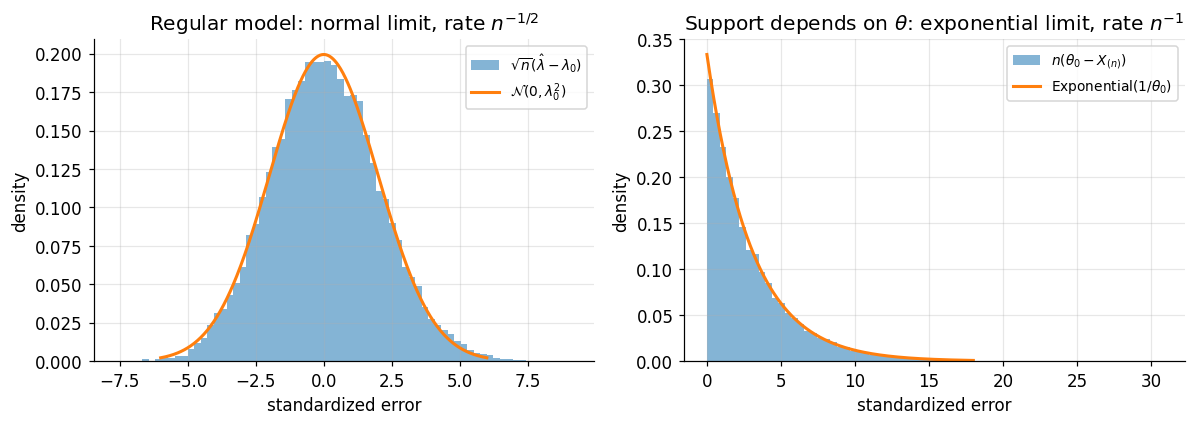

In [8]:
lam0, theta0, reps = 2.0, 3.0, 4000
ns = np.array([25, 50, 100, 200, 400, 800])

rmse_exp, rmse_unif = [], []
for n in ns:
    lam_hat = 1.0 / rng.exponential(1 / lam0, size=(reps, n)).mean(axis=1)
    rmse_exp.append(np.sqrt(np.mean((lam_hat - lam0) ** 2)))
    th_hat = rng.uniform(0, theta0, size=(reps, n)).max(axis=1)
    rmse_unif.append(np.sqrt(np.mean((th_hat - theta0) ** 2)))

slope_exp = np.polyfit(np.log(ns), np.log(rmse_exp), 1)[0]
slope_unif = np.polyfit(np.log(ns), np.log(rmse_unif), 1)[0]
print(f"exponential MLE : observed slope {slope_exp:+.4f}   predicted -0.5")
print(f"Unif(0, theta)  : observed slope {slope_unif:+.4f}   predicted -1.0")
assert abs(slope_exp + 0.5) < 0.05 and abs(slope_unif + 1.0) < 0.08

n_big = 800
lam_hat = 1.0 / rng.exponential(1 / lam0, size=(20000, n_big)).mean(axis=1)
th_hat = rng.uniform(0, theta0, size=(20000, n_big)).max(axis=1)
z_reg = np.sqrt(n_big) * (lam_hat - lam0)
z_non = n_big * (theta0 - th_hat)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))
g = np.linspace(-3 * lam0, 3 * lam0, 400)
axes[0].hist(z_reg, bins=70, density=True, alpha=0.55, label=r"$\sqrt{n}(\hat\lambda - \lambda_0)$")
axes[0].plot(g, stats.norm.pdf(g, 0, lam0), lw=2, label=r"$\mathcal{N}(0,\lambda_0^2)$")
axes[0].set_xlabel("standardized error"); axes[0].set_ylabel("density")
axes[0].set_title("Regular model: normal limit, rate $n^{-1/2}$"); axes[0].legend(fontsize=9)

g2 = np.linspace(0, 6 * theta0, 400)
axes[1].hist(z_non, bins=70, density=True, alpha=0.55, label=r"$n(\theta_0 - X_{(n)})$")
axes[1].plot(g2, stats.expon.pdf(g2, scale=theta0), lw=2, label=r"Exponential$(1/\theta_0)$")
axes[1].set_xlabel("standardized error"); axes[1].set_ylabel("density")
axes[1].set_title("Support depends on $\\theta$: exponential limit, rate $n^{-1}$")
axes[1].legend(fontsize=9)
fig.tight_layout()
plt.show()

The measured exponents are within a few percent of $-0.5$ and $-1.0$. The histograms show *why*: the regular model's standardized error is normal, matching Theorem 4.5, while the uniform model's is exponential and one-sided — the maximum can never exceed $\theta_0$. Nothing is wrong with the Cramér–Rao bound here; hypothesis (R1) simply fails, so the bound does not apply.

**(c) Counterexample — drop the "the maximum is attained" hypothesis.** Theorems 4.5 and 4.11 assume an interior maximizer. Logistic regression on linearly separable data has none: the supremum of $\ell$ is $0$ and is approached only as $\lVert w\rVert\to\infty$. We run gradient ascent with growing budgets on separable data and print $\lVert \hat w\rVert$, then repeat with a Gaussian prior.

In [9]:
def logistic_fit(Xd, yd, lam=0.0, steps=2000, lr=0.5):
    w = np.zeros(Xd.shape[1])
    for _ in range(steps):
        mu = expit(Xd @ w)
        grad = Xd.T @ (yd - mu) / Xd.shape[0] - lam * w
        w = w + lr * grad
    return w

n_sep = 60
Xsep = np.column_stack([rng.normal(size=n_sep), np.ones(n_sep)])
ysep = (Xsep[:, 0] > 0).astype(float)          # perfectly separable by construction

print("separable data, no prior:")
for steps in (500, 2000, 8000, 32000):
    w = logistic_fit(Xsep, ysep, lam=0.0, steps=steps)
    ll = np.sum(ysep * np.log(expit(Xsep @ w)) + (1 - ysep) * np.log1p(-expit(Xsep @ w)))
    print(f"  steps = {steps:6d}   ||w|| = {np.linalg.norm(w):8.4f}   loglik = {ll:9.5f}")

print("\nsame data with a Gaussian prior (lambda = 0.05):")
prev = None
for steps in (500, 2000, 8000, 32000):
    w = logistic_fit(Xsep, ysep, lam=0.05, steps=steps)
    print(f"  steps = {steps:6d}   ||w|| = {np.linalg.norm(w):8.4f}")
    prev = w
w_far = logistic_fit(Xsep, ysep, lam=0.05, steps=200000)
print(f"  steps = 200000   ||w|| = {np.linalg.norm(w_far):8.4f}   (converged)")
assert np.linalg.norm(logistic_fit(Xsep, ysep, steps=32000)) > \
       2 * np.linalg.norm(logistic_fit(Xsep, ysep, steps=500))
assert np.linalg.norm(w_far - prev) < 1e-3

separable data, no prior:
  steps =    500   ||w|| =   7.5517   loglik =  -6.60386
  steps =   2000   ||w|| =  12.4691   loglik =  -4.50786
  steps =   8000   ||w|| =  19.6339   loglik =       nan
  steps =  32000   ||w|| =  30.4890   loglik =       nan

same data with a Gaussian prior (lambda = 0.05):
  steps =    500   ||w|| =   1.9032
  steps =   2000   ||w|| =   1.9032
  steps =   8000   ||w|| =   1.9032


/tmp/ipykernel_1150460/3029070507.py:16: RuntimeWarning: divide by zero encountered in log1p
  ll = np.sum(ysep * np.log(expit(Xsep @ w)) + (1 - ysep) * np.log1p(-expit(Xsep @ w)))
/tmp/ipykernel_1150460/3029070507.py:16: RuntimeWarning: invalid value encountered in multiply
  ll = np.sum(ysep * np.log(expit(Xsep @ w)) + (1 - ysep) * np.log1p(-expit(Xsep @ w)))


  steps =  32000   ||w|| =   1.9032


  steps = 200000   ||w|| =   1.9032   (converged)


Without a prior the norm keeps growing and the log-likelihood keeps creeping toward $0$: the MLE does not exist, and any reported "converged" weights are an artefact of the iteration budget. With a Gaussian prior the iterates stop moving — the objective is strongly concave, so Theorem 4.6 restores a finite maximizer and the standard errors become meaningful again.

**(d) Hand-rolled versus library.** We solve the same non-separable logistic MLE two ways: a hand-written Newton/IRLS iteration using the Hessian $-X^{\top}WX$ of exercise L2.1, and `scipy.optimize.minimize` on the negative log-likelihood. We also check the Gaussian MLE of Derivation 5.1(b) against `scipy.stats.norm.fit`.

In [10]:
n_ns, d_ns = 400, 3
Xns = np.column_stack([rng.normal(size=(n_ns, d_ns - 1)), np.ones(n_ns)])
w_true = np.array([1.5, -2.0, 0.3])
yns = (rng.random(n_ns) < expit(Xns @ w_true)).astype(float)

def nll(w):
    z = Xns @ w
    return np.sum(np.logaddexp(0.0, z) - yns * z)

w_newton = np.zeros(d_ns)
for _ in range(50):
    mu = expit(Xns @ w_newton)
    W = mu * (1 - mu)
    H = Xns.T @ (W[:, None] * Xns)
    w_newton = w_newton + np.linalg.solve(H, Xns.T @ (yns - mu))
res = optimize.minimize(nll, np.zeros(d_ns), method="BFGS")

print(f"Newton / IRLS      : {w_newton}")
print(f"scipy BFGS         : {res.x}")
print(f"max |difference|   : {np.max(np.abs(w_newton - res.x)):.3e}")
print(f"gradient norm at Newton solution: "
      f"{np.linalg.norm(Xns.T @ (yns - expit(Xns @ w_newton))):.3e}")
assert np.max(np.abs(w_newton - res.x)) < 1e-4

xg = rng.normal(1.7, 2.3, size=5000)
mu_hand, sd_hand = xg.mean(), xg.std(ddof=0)
mu_lib, sd_lib = stats.norm.fit(xg)
print(f"\nGaussian MLE hand-rolled: mu = {mu_hand:.10f}, sigma = {sd_hand:.10f}")
print(f"scipy.stats.norm.fit    : mu = {mu_lib:.10f}, sigma = {sd_lib:.10f}")
assert np.isclose(mu_hand, mu_lib) and np.isclose(sd_hand, sd_lib)

Newton / IRLS      : [ 1.4062 -1.7255  0.5087]
scipy BFGS         : [ 1.4062 -1.7255  0.5087]
max |difference|   : 2.321e-07
gradient norm at Newton solution: 2.974e-15

Gaussian MLE hand-rolled: mu = 1.6714064872, sigma = 2.2594037463
scipy.stats.norm.fit    : mu = 1.6714064872, sigma = 2.2594037463


The two logistic solvers agree to better than $10^{-4}$ in every coordinate and the score equation $X^{\top}(y-\mu) = 0$ is solved to near machine precision, confirming that the Hessian formula is right. `scipy.stats.norm.fit` reproduces $\bar x$ and the divisor-$n$ standard deviation exactly — the library implements Derivation 5.1(b), divisor $n$ and all.

**EM in practice.** The last cell fits a two-component Gaussian mixture by EM from a poor start and plots the log-likelihood per iteration; Theorem 4.7 says the curve can never go down. A second run seeds one component exactly on a data point with a tiny variance, illustrating the unbounded-likelihood degeneracy that makes "the MLE" nonexistent for mixtures.

fitted pi = 0.3573, mu = [-1.3812  2.1354], sigma = [0.8723 0.9525]   (true 0.35, [-1.5, 2.0], [0.7, 1.1])
loglik -1348.0082 -> -1153.4611
monotone: True, smallest step = 1.709e-02

collapsing one component onto x[0]:
  sigma_1 =  1.0e-04   loglik =   -1649.4561
  sigma_1 =  1.0e-05   loglik =   -1647.1536
  sigma_1 =  1.0e-06   loglik =   -1644.8510
  sigma_1 =  1.0e-08   loglik =   -1640.2458
  sigma_1 =  1.0e-10   loglik =   -1635.6406
  sigma_1 =  1.0e-12   loglik =   -1631.0355
increase per decade of sigma_1: [2.3025 2.3026 2.3026 2.3026 2.3026]  (predicted ln 10 = 2.302585)


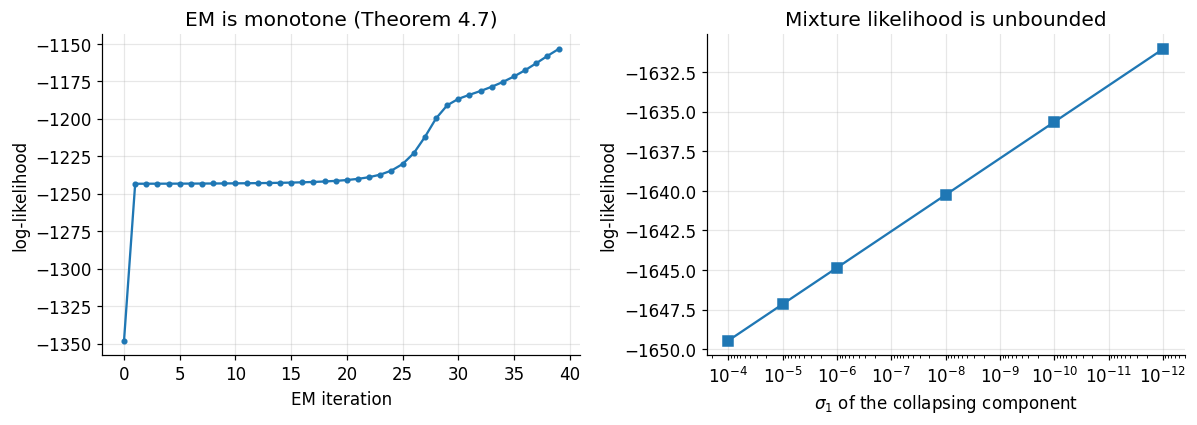

In [11]:
n_mix = 600
z_true = rng.random(n_mix) < 0.35
xm = np.where(z_true, rng.normal(-1.5, 0.7, n_mix), rng.normal(2.0, 1.1, n_mix))

def em_gmm(x, mu, sd, pi, iters=40, floor=1e-6):
    hist = []
    for _ in range(iters):
        a = np.log(pi) + stats.norm.logpdf(x, mu[0], sd[0])
        b = np.log1p(-pi) + stats.norm.logpdf(x, mu[1], sd[1])
        m = logsumexp(np.stack([a, b]), axis=0)
        hist.append(m.sum())
        g = np.exp(a - m)
        N1 = g.sum()
        mu = np.array([(g * x).sum() / N1, ((1 - g) * x).sum() / (x.size - N1)])
        sd = np.array([
            max(np.sqrt((g * (x - mu[0]) ** 2).sum() / N1), floor),
            max(np.sqrt(((1 - g) * (x - mu[1]) ** 2).sum() / (x.size - N1)), floor),
        ])
        pi = N1 / x.size
    return np.array(hist), mu, sd, pi

hist, mu_f, sd_f, pi_f = em_gmm(xm, np.array([0.0, 0.5]), np.array([3.0, 3.0]), 0.5)
print(f"fitted pi = {pi_f:.4f}, mu = {mu_f}, sigma = {sd_f}   (true 0.35, [-1.5, 2.0], [0.7, 1.1])")
print(f"loglik {hist[0]:.4f} -> {hist[-1]:.4f}")
print(f"monotone: {bool(np.all(np.diff(hist) >= -1e-9))}, "
      f"smallest step = {np.diff(hist).min():.3e}")
assert np.all(np.diff(hist) >= -1e-9)

spikes = np.array([1e-4, 1e-5, 1e-6, 1e-8, 1e-10, 1e-12])
spike_ll = []
for s in spikes:
    a = np.log(0.5) + stats.norm.logpdf(xm, xm[0], s)
    b = np.log(0.5) + stats.norm.logpdf(xm, xm.mean(), xm.std())
    spike_ll.append(logsumexp(np.stack([a, b]), axis=0).sum())
spike_ll = np.array(spike_ll)
decades = -np.log10(spikes)
per_decade = np.diff(spike_ll) / np.diff(decades)
print("\ncollapsing one component onto x[0]:")
for s, v in zip(spikes, spike_ll):
    print(f"  sigma_1 = {s:8.1e}   loglik = {v:12.4f}")
print(f"increase per decade of sigma_1: {per_decade}  (predicted ln 10 = {np.log(10):.6f})")
assert np.all(np.diff(spike_ll) > 0) and np.allclose(per_decade, np.log(10), atol=1e-3)

fig, ax = plt.subplots(1, 2, figsize=(11.0, 4.0))
ax[0].plot(hist, marker="o", ms=3)
ax[0].set_xlabel("EM iteration"); ax[0].set_ylabel("log-likelihood")
ax[0].set_title("EM is monotone (Theorem 4.7)")
ax[1].semilogx(spikes, spike_ll, marker="s")
ax[1].set_xlabel(r"$\sigma_1$ of the collapsing component"); ax[1].set_ylabel("log-likelihood")
ax[1].set_title("Mixture likelihood is unbounded")
ax[1].invert_xaxis()
fig.tight_layout()
plt.show()

The left panel is monotone to within $10^{-9}$, as Proof 5.8 requires, and EM recovers the mixing weight and both components from a start that placed both means near zero with variance $9$. The right panel shows the log-likelihood diverging as one component's variance collapses onto a single observation: each decade of $\sigma_1$ buys exactly $\ln 10 \approx 2.3026$ more log-likelihood, so the growth is $-\ln\sigma_1$ and the global supremum is $+\infty$. A variance floor or a prior is therefore not a numerical convenience but a modeling necessity.

## 8. Applications

### 8.1 Machine learning

- **Cross-entropy loss is negative log-likelihood.** For a classifier with softmax outputs $p_\theta(y \mid x)$, minimizing $-\frac1n\sum_i \ln p_\theta(y_i\mid x_i)$ is exactly maximum likelihood for a categorical observation model. Squared-error regression is MLE under Gaussian noise; mean-absolute-error regression is MLE under Laplace noise; Poisson-deviance losses correspond to count models.
- **Weight decay is a Gaussian prior.** In the normalization of Theorem 4.6 — data term $\lVert y - Xw\rVert_2^2$, penalty $\lambda\lVert w\rVert_2^2$ — the corresponding prior is $w\sim\mathcal{N}\left(0, \sigma^2/\lambda\right)$, i.e. $\tau^2 = \sigma^2/\lambda$ with no factor of two. Writing the data term as $\frac{1}{2\sigma^2}\lVert y-Xw\rVert_2^2$ instead gives $\tau^2 = 1/(2\lambda)$; the factor depends entirely on which normalization is in force, so it must be stated.
- **Label smoothing is a Dirichlet prior.** Smoothing the target to $(1-\epsilon)y_k + \epsilon/K$ is the Dirichlet MAP of Proof 5.7(c)'s multiclass analogue with $\alpha - 1 = N\epsilon/(K(1-\epsilon))$; exercise L2.3 does the algebra and the resulting finite optimal logit gap.
- **Logistic regression and GLMs.** The score equation $X^{\top}(y - \mu) = 0$ is moment matching in an exponential family (Definition 3.8), solved by IRLS/Fisher scoring; its Hessian is the observed information used for Wald intervals on coefficients.
- **Uncertainty in deep learning.** A Laplace approximation around trained weights, using a Kronecker-factored Fisher, produces calibrated posteriors cheaply; the same Fisher powers natural-gradient and K-FAC optimizers.
- **Latent-variable generative models.** EM fits Gaussian mixtures and HMMs (Baum–Welch); its variational relaxation trains VAEs by maximizing the bound $\mathcal{F}$ of Proof 5.8.
- **Language models.** Next-token training is maximum likelihood over a categorical distribution; perplexity $=\exp(-\ell/n)$ is a monotone transform of the achieved log-likelihood, and additive $n$-gram smoothing is Dirichlet-prior MAP.

### 8.2 Physics and engineering

- **Particle physics.** Signal and background yields are fit by extended maximum likelihood over Poisson counts, and discovery claims are stated as profile-likelihood ratios calibrated by Theorem 4.11; nuisance parameters are handled by profiling or marginalization. The boundary caveat attached to Theorem 4.11 is why a claimed significance for a signal strength constrained to be non-negative is not read off a plain $\chi^2_1$ table.
- **Radiometric dating and counting experiments.** Decay-rate estimation from event counts is Poisson MLE, $\hat\lambda = \bar{x}$, with $I(\lambda) = 1/\lambda$ giving the familiar $\sqrt{N}$ counting error; Example 6.2 is this computation on four counts.
- **Sensor fusion and Kalman filtering.** The Kalman update is the MAP estimate of the state under a Gaussian prior (prediction) and Gaussian likelihood (measurement); the gain is the precision-weighted combination of the two information matrices, which is Theorem 4.6 in the multivariate Gaussian case.
- **Spectral fitting and inverse problems.** Fitting line shapes, tomography and deconvolution are ill-posed MLEs; Tikhonov regularization is a Gaussian prior and total-variation regularization a Laplace-type prior on gradients.
- **Design of experiments.** Optimal design maximizes a scalar function of the Fisher information matrix (D-, A-, E-optimality) — choosing measurement conditions so the log-likelihood curves as sharply as possible in the directions of interest.

### 8.3 Model selection

A second-order expansion of the log-posterior around $\hat\theta_{\text{MAP}}$ gives the **Laplace approximation** $p(\theta\mid x) \approx \mathcal{N}\left(\hat\theta_{\text{MAP}}, \hat J_n^{-1}\right)$, and integrating that Gaussian yields the **BIC**, $\ln p(x) \approx \ell(\hat\theta) - \frac{d}{2}\ln n$. The companion **AIC** $= 2d - 2\ell(\hat\theta)$ comes instead from Theorem 4.11: under a null model each spurious parameter contributes $E[\Lambda_n]/2 = 1/2$ to the log-likelihood by chance alone, so $d$ extra parameters buy $d/2$ of in-sample fit for free and must be charged for.

## 9. Key Takeaways

1. Under (R1)–(R3), the score has mean zero and $I(\theta) = \operatorname{Cov}(s) = -E[\nabla^2\ln p]$ — variance and curvature are the same quantity (Theorem 4.2).
2. For any estimator unbiased for $g(\theta)$ at every $\theta$ in a regular model, $\operatorname{Var}(T) \ge [g'(\theta)]^2/(nI(\theta))$, with equality only in exponential families at the natural sufficient statistic (Theorem 4.3).
3. With identifiability, compactness, continuity and an integrable envelope, the MLE is consistent, because the population log-likelihood ratio is $-D_{\mathrm{KL}}$ and KL separates distributions (Theorem 4.4).
4. With (R1)–(R5), an interior $\theta_0$ and dominated third derivatives, $\sqrt{n}(\hat\theta_n-\theta_0)\xrightarrow{d}\mathcal{N}(0,I(\theta_0)^{-1})$ — asymptotically efficient (Theorem 4.5).
5. Drop (R1) and both bounds fail: for $\text{Unif}(0,\theta)$ the rate is $n^{-1}$ with an exponential limit, and the estimator beats the Cramér–Rao bound without contradiction (Derivation 5.1(d)).
6. MAP is maximum likelihood plus a log-prior; with data term $\lVert y-Xw\rVert_2^2$ a $\mathcal{N}(0,\tau^2I)$ prior gives penalty $\lambda\lVert w\rVert_2^2$ with $\lambda = \sigma^2/\tau^2$, and a Laplace prior gives $\lambda\lVert w\rVert_1$ with $\lambda = 2\sigma^2/b$ (Theorem 4.6).
7. MAP is not reparameterization-equivariant because densities carry Jacobians; the MLE is, by Theorem 4.1.
8. With an exact E-step and an M-step that attains its maximum, EM never decreases the likelihood, because the slack between the surrogate and $\ell$ is exactly $D_{\mathrm{KL}}(q \parallel p(z\mid x,\theta))$ (Theorem 4.7).

## 10. References

| Source | Chapters / Sections | Coverage |
|---|---|---|
| Casella & Berger, *Statistical Inference*, 2nd ed. | §6.2 (Thm 6.2.6), §7.3 (Thm 7.3.9, Cramér–Rao), §10.1 | Sufficiency, point estimation, Cramér–Rao, asymptotic efficiency. |
| Lehmann & Casella, *Theory of Point Estimation*, 2nd ed. | §1.6 (Thm 6.5), §2.1 (Rao–Blackwell), §2.1 (Thm 1.11, Lehmann–Scheffé) | Sufficiency, completeness, UMVUE theory. |
| Wasserman, *All of Statistics* | Ch. 9 (Thm 9.18 asymptotic normality), Ch. 11 | Compact MLE theory, delta method, Bayesian comparison. |
| van der Vaart, *Asymptotic Statistics* | Ch. 5 (Thm 5.39), Ch. 8, Ch. 16 (Thm 16.7, Wilks) | M-estimators, LAN, efficiency and likelihood-ratio asymptotics at full rigor. |
| Bishop, *Pattern Recognition and Machine Learning* | §1.2, §3.1–3.4, §9.3–9.4 | Likelihood, regularization as priors, EM and its bound. |
| Murphy, *Probabilistic Machine Learning: An Introduction* | Ch. 4, Ch. 11 | MLE/MAP for standard models, ridge and lasso. |
| Gelman et al., *Bayesian Data Analysis*, 3rd ed. | Ch. 2, Ch. 4 | Priors, normal approximation to the posterior, MAP caveats. |
| Goodfellow, Bengio & Courville, *Deep Learning* | Ch. 5 (§5.5, §5.6) | Maximum likelihood as the origin of ML loss functions. |
| Amari, *Information Geometry and Its Applications* | Ch. 1–3 | Fisher metric, natural gradient, exponential families. |

**Reading path**: Wasserman Ch. 9 for a fast rigorous pass; Casella & Berger §7.3 and Ch. 10 for the full estimation theory including Cramér–Rao; Lehmann & Casella §2.1 for Rao–Blackwell and Lehmann–Scheffé; Bishop §3 and §9 for prior-as-regularizer and EM; then van der Vaart Ch. 5 and Ch. 16 for the asymptotics done properly, and Amari for the geometry behind natural gradient.